In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hdbcli import dbapi
import pandas as pd
from sklearn.ensemble import IsolationForest
import joblib
import os
import json
from dotenv import load_dotenv


In [79]:

# 1. Leer el CSV local
print("Cargando datos locales...")
df = pd.read_csv('datos_entrenamiento.csv')


Cargando datos locales...


In [80]:
df.columns

Index(['EVENT_HASH', 'TIMESTAMP', 'SOURCE_IP', 'LOCATION', 'SERVICE_ID',
       'LLM_PROVIDER', 'LLM_MODEL_ID', 'LLM_PROMPT', 'LLM_TOTAL_TOKENS',
       'LLM_COST_USD', 'LLM_RESPONSE_TIME_MS', 'HTTP_STATUS_CODE',
       'ANOMALY_SCORE', 'LABEL', 'HEADERS_CONTENT_TYPE', 'LLM_PROMPT_CATEGORY',
       'LLM_STATUS'],
      dtype='str')

In [81]:

cols = [
    "EVENT_HASH",
    "TIMESTAMP",
    "SOURCE_IP",
    "LOCATION",
    "SERVICE_ID",
    'LLM_PROVIDER',
    'LLM_PROVIDER',
    "LLM_PROMPT",
    "LLM_TOTAL_TOKENS",
    "LLM_COST_USD",
    "LLM_RESPONSE_TIME_MS",
    "HTTP_STATUS_CODE",
    "ANOMALY_SCORE",
    "LABEL", 
    "HEADERS_CONTENT_TYPE", 
    "LLM_PROMPT_CATEGORY",
    "LLM_STATUS"
]


cols = list(dict.fromkeys(cols))

# Validar columnas antes de filtrar
missing_cols = [c for c in cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Estas columnas de cols no existen en el dataframe: {missing_cols}")

df = df[cols].copy()

df.head()

,EVENT_HASH,TIMESTAMP,SOURCE_IP,LOCATION,SERVICE_ID,LLM_PROVIDER,LLM_PROMPT,LLM_TOTAL_TOKENS,LLM_COST_USD,LLM_RESPONSE_TIME_MS,HTTP_STATUS_CODE,ANOMALY_SCORE,LABEL,HEADERS_CONTENT_TYPE,LLM_PROMPT_CATEGORY,LLM_STATUS
0,4eadcf438dfd5d46f640bdd3618de24c2a32ecc9fa078cd4b164b062e52b35ab,2026-05-04 09:59:58,Unknown,USA | East,NaN,Mistral,Compare the accuracy and latency of available LLM models for the sap-s4hana-finance use case in USA | East.,2158,0.000539,3152,0,NaN,NaN,text/plain,LLM Operations,success
1,ff3fedf4c5c9066fa303f88c5fa6100745d8dc875714f0150229d75338f411bb,2026-05-04 09:59:57,Unknown,Turkey | Lenovo CE (Primary),NaN,Mistral,Audit context window usage for sap-fiori-launchpad LLM calls and recommend chunking strategies to reduce truncation.,3170,0.000951,8855,0,NaN,NaN,multipart/form-data,LLM Operations,success
2,edef5682648a22e2c87b88b267e60bfd78ed17f41f5d550ece00f94238554ac0,2026-05-04 09:59:57,Unknown,South Africa | Johannesburg (2),NaN,OpenAI,Perform a cohort analysis of sap-s4hana-sales users in South Africa | Johannesburg (2) who onboarded in Q3.,1571,0.047130,34859,0,NaN,NaN,text/plain,Analytics,timeout
3,8ebac03701812155a4c26c884bddd4d0dd832a8ea97ebefef30defc0befd6fa1,2026-05-04 09:59:55,Unknown,India | Delhi,NaN,Google,Benchmark compensation for sap-concur roles in India | Delhi against current market data.,2003,0.014021,8365,0,NaN,NaN,application/x-www-form-urlencoded,HR,success
4,083d86d62e156e0ac25574a506d120dbfabaa68897daa0cacf274cf2f70e5334,2026-05-04 09:59:54,Unknown,USA | Washington DC,NaN,Anthropic,Create a corrective action plan for overdue invoices in sap-fiori-launchpad.,1987,0.005961,7648,0,NaN,NaN,multipart/form-data,Finance,success


### Preprocesamiento

In [82]:
df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"], errors="coerce")

In [83]:
num_cols = [
    "LLM_TOTAL_TOKENS",
    "LLM_COST_USD",
    "LLM_RESPONSE_TIME_MS",
    "HTTP_STATUS_CODE"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [84]:
# reemplaza strings vacíos o con espacios por NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

### Feature engineering

In [85]:
# filtrar solo requests LLM válidos
df_llm = df[
    df["LLM_TOTAL_TOKENS"].notna() &
    df["LLM_TOTAL_TOKENS"] > 0 &
    df["LLM_PROMPT"].notna()
].copy()

In [86]:
# =========================
# FEATURES TEMPORALES
# =========================

df_llm["TIMESTAMP"] = pd.to_datetime(df_llm["TIMESTAMP"], errors="coerce")

# Eliminar registros sin fecha si quieres usar análisis temporal
df_llm = df_llm[df_llm["TIMESTAMP"].notna()].copy()

df_llm["hour"] = df_llm["TIMESTAMP"].dt.hour
df_llm["day_of_week"] = df_llm["TIMESTAMP"].dt.dayofweek
df_llm["day_of_month"] = df_llm["TIMESTAMP"].dt.day
df_llm["month"] = df_llm["TIMESTAMP"].dt.month

df_llm["is_night"] = df_llm["hour"].between(0, 5).astype(int)
df_llm["is_weekend"] = df_llm["day_of_week"].isin([5, 6]).astype(int)

# Ventanas por minuto
df_llm["minute_window"] = df_llm["TIMESTAMP"].dt.floor("min")

traffic_per_minute = (
    df_llm.groupby("minute_window")
    .size()
    .rename("requests_per_minute")
)

errors_per_minute = (
    df_llm.assign(is_error=df_llm["LLM_STATUS"].isin(["error", "timeout"]).astype(int))
    .groupby("minute_window")["is_error"]
    .sum()
    .rename("errors_per_minute")
)

avg_latency_per_minute = (
    df_llm.groupby("minute_window")["LLM_RESPONSE_TIME_MS"]
    .mean()
    .rename("avg_latency_per_minute")
)

tokens_per_minute = (
    df_llm.groupby("minute_window")["LLM_TOTAL_TOKENS"]
    .sum()
    .rename("tokens_per_minute")
)

df_llm = df_llm.merge(
    traffic_per_minute,
    on="minute_window",
    how="left"
)

df_llm = df_llm.merge(
    errors_per_minute,
    on="minute_window",
    how="left"
)

df_llm = df_llm.merge(
    avg_latency_per_minute,
    on="minute_window",
    how="left"
)

df_llm = df_llm.merge(
    tokens_per_minute,
    on="minute_window",
    how="left"
)

df_llm[[
    "TIMESTAMP",
    "LOCATION",
    "hour",
    "is_night",
    "requests_per_minute",
    "errors_per_minute",
    "tokens_per_minute"
]].head()

,TIMESTAMP,LOCATION,hour,is_night,requests_per_minute,errors_per_minute,tokens_per_minute
0,2026-05-04 09:59:57,South Africa | Johannesburg (2),9,0,33,10,58839
1,2026-05-04 09:59:55,India | Delhi,9,0,33,10,58839
2,2026-05-04 09:59:54,USA | Washington DC,9,0,33,10,58839
3,2026-05-04 09:59:51,India | Hyderabad,9,0,33,10,58839
4,2026-05-04 09:59:50,Switzerland | Zürich,9,0,33,10,58839


In [87]:
# longitud del prompt
df_llm["prompt_length"] = df_llm["LLM_PROMPT"].astype(str).str.len()

# evitar divisiones inválidas
df_llm["prompt_length"] = df_llm["prompt_length"].replace(0, np.nan)

# features
df_llm["token_density"] = df_llm["LLM_TOTAL_TOKENS"] / df_llm["prompt_length"]
df_llm["latency_per_token"] = df_llm["LLM_RESPONSE_TIME_MS"] / df_llm["LLM_TOTAL_TOKENS"]
df_llm["cost_intensity"] = df_llm["LLM_COST_USD"] / df_llm["LLM_TOTAL_TOKENS"]


In [88]:
# % de valores nulos
pct_null = df_llm.isna().mean() * 100
pct_null

EVENT_HASH                  0.000000
TIMESTAMP                   0.000000
SOURCE_IP                  50.417216
LOCATION                    0.000000
SERVICE_ID                100.000000
LLM_PROVIDER                0.000000
LLM_PROMPT                  0.000000
LLM_TOTAL_TOKENS            0.000000
LLM_COST_USD                0.000000
LLM_RESPONSE_TIME_MS        0.000000
HTTP_STATUS_CODE            0.000000
ANOMALY_SCORE             100.000000
LABEL                     100.000000
HEADERS_CONTENT_TYPE        0.000000
LLM_PROMPT_CATEGORY         0.000000
LLM_STATUS                  0.000000
hour                        0.000000
day_of_week                 0.000000
day_of_month                0.000000
month                       0.000000
is_night                    0.000000
is_weekend                  0.000000
minute_window               0.000000
requests_per_minute         0.000000
errors_per_minute           0.000000
avg_latency_per_minute      0.000000
tokens_per_minute           0.000000
p

In [89]:
df_llm = df_llm.copy()

In [90]:
df[cols].sample(10)

,EVENT_HASH,TIMESTAMP,SOURCE_IP,LOCATION,SERVICE_ID,LLM_PROVIDER,LLM_PROMPT,LLM_TOTAL_TOKENS,LLM_COST_USD,LLM_RESPONSE_TIME_MS,HTTP_STATUS_CODE,ANOMALY_SCORE,LABEL,HEADERS_CONTENT_TYPE,LLM_PROMPT_CATEGORY,LLM_STATUS
1566,fb22c4dfb4a73d03f6d3aff879b21f568498457599e8e75fe4f264a86f7077ad,2026-05-04 09:38:28,Unknown,"USA | Chandler, AZ",NaN,Anthropic,"Query SAP Joule for the current headcount breakdown by department in sap-s4hana-finance for USA | Chandler, AZ.",1343,0.004029,11856,0,NaN,NaN,application/json,SAP Joule,success
4236,a97851d0841f399ee8f4cf97c68e79e3b12517d9c25a2f1ae1b16cf7ed7b0704,2026-05-04 09:03:43,NaN,Switzerland | Geneva,NaN,Google,Recommend a rate-limiting policy for sap-fiori-launchpad based on current consumer traffic patterns in Switzerland | Geneva.,1002,0.000075,5447,0,NaN,NaN,application/x-www-form-urlencoded,API Operations,success
1087,22b496be7131fc6eeb011822a7351343b3ac3a72c74eb403edeb606ef2e6da83,2026-05-04 09:45:08,Unknown,Malaysia | Cyberjaya,NaN,Mistral,Draft a weekly status update for the sap-data-sphere project in Malaysia | Cyberjaya suitable for senior stakeholders.,2537,0.000634,9435,0,NaN,NaN,text/plain,Productivity,success
465,7c8a0294c79c6d16392f660ed6f06b742703eea2514431a49da979cc2a448664,2026-05-04 09:53:33,Unknown,Indonesia | Jakarta,NaN,NVIDIA,Analyse procurement spend for sap-analytics-cloud in Indonesia | Jakarta during Q1 and identify savings opportunities.,1144,0.004576,11973,0,NaN,NaN,application/json,Procurement,success
4388,7afea83909232124bc705fc7b55ddbd5a245596824e1ad73b8d7c4cca03f2368,2026-05-04 09:01:37,NaN,Bahrain,NaN,OpenAI,Explain the following email in plain language and highlight any action items: RFC_COMMUNICATION_FAILURE.,3093,0.092790,7425,0,NaN,NaN,application/xml,Productivity,success
1815,8a03227ef1eb399cf14bfe8d503fdc5308976fc12635da4aaf64142b547e1dd4,2026-05-04 09:35:03,Unknown,Singapore,NaN,OpenAI,Review data retention policies for sap-fiori-launchpad in Singapore and flag records exceeding retention limits.,1138,0.022760,1540,0,NaN,NaN,multipart/form-data,Compliance,success
1914,f113fe10dddb247789239311e433b84f01ae519358240ff74296f03875eb702d,2026-05-04 09:33:47,Unknown,Switzerland | Geneva,NaN,Anthropic,Analyse leave utilisation patterns for the sap-concur team in Switzerland | Geneva during Q2 and flag any compliance concerns.,2361,0.007083,8758,0,NaN,NaN,application/xml,HR,success
329,7b0c40c48515c77327523824e4d2f30be83bd2179c13f120f96f631b07aac747,2026-05-04 09:55:17,Unknown,India | Mumbai,NaN,Anthropic,Draft a capital expenditure approval request for the sap-ariba infrastructure upgrade in India | Mumbai.,1786,0.032148,4444,0,NaN,NaN,text/plain,Finance,success
4441,316409b918309dd36420d8e2561d721167f899722ebca6e175ff99b1ab7b2d30,2026-05-04 09:00:49,NaN,Chile | Santiago,NaN,Anthropic,Ask SAP Joule to explain the inventory discrepancy detected in sap-successfactors for region Chile | Santiago.,2702,0.008106,4905,0,NaN,NaN,application/x-www-form-urlencoded,SAP Joule,success
68,aa9b359e9902e80d22a307ec592785aa3c981f41bed39dbd0e44c10e7600bbf9,2026-05-04 09:59:00,Unknown,United Arab Emirates,NaN,Google,Evaluate supplier lead time variability for NexaGroup and its impact on sap-ariba production schedules.,2561,0.017927,7102,0,NaN,NaN,multipart/form-data,Supply Chain,success


In [91]:
print("Shape df original:", df.shape)
print("Shape df_llm:", df_llm.shape)

print("\nRegistros con LLM_TOTAL_TOKENS no nulo:")
print(df["LLM_TOTAL_TOKENS"].notna().sum())

print("\nRegistros con LLM_TOTAL_TOKENS > 0:")
print((df["LLM_TOTAL_TOKENS"] > 0).sum())

print("\nRegistros con LLM_PROMPT no nulo:")
print(df["LLM_PROMPT"].notna().sum())

print("\nRegistros que cumplen ambas condiciones:")
print((
    df["LLM_TOTAL_TOKENS"].notna() &
    (df["LLM_TOTAL_TOKENS"] > 0) &
    df["LLM_PROMPT"].notna()
).sum())

Shape df original: (4505, 16)
Shape df_llm: (2277, 31)

Registros con LLM_TOTAL_TOKENS no nulo:
4505

Registros con LLM_TOTAL_TOKENS > 0:
4505

Registros con LLM_PROMPT no nulo:
4505

Registros que cumplen ambas condiciones:
4505


## EDA

In [92]:


# columnas categóricas
cat_cols = [
    "LOCATION",
    "LLM_PROVIDER",
    "HEADERS_CONTENT_TYPE",
    "LLM_PROMPT_CATEGORY",
    "LLM_STATUS"
]

# usar solo las que existan en df_llm
cat_cols = [c for c in cat_cols if c in df_llm.columns]

# numérica creada en feature engineering
num_cols = ["prompt_length"]

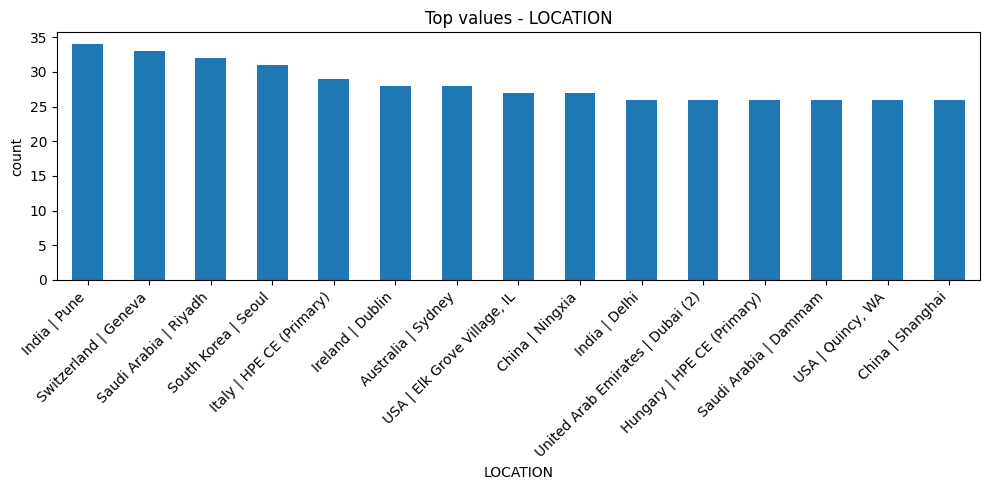

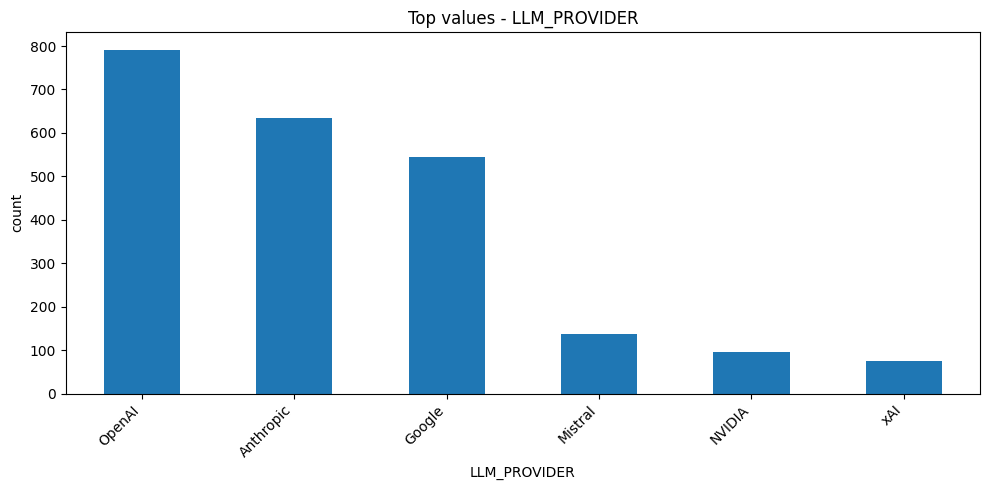

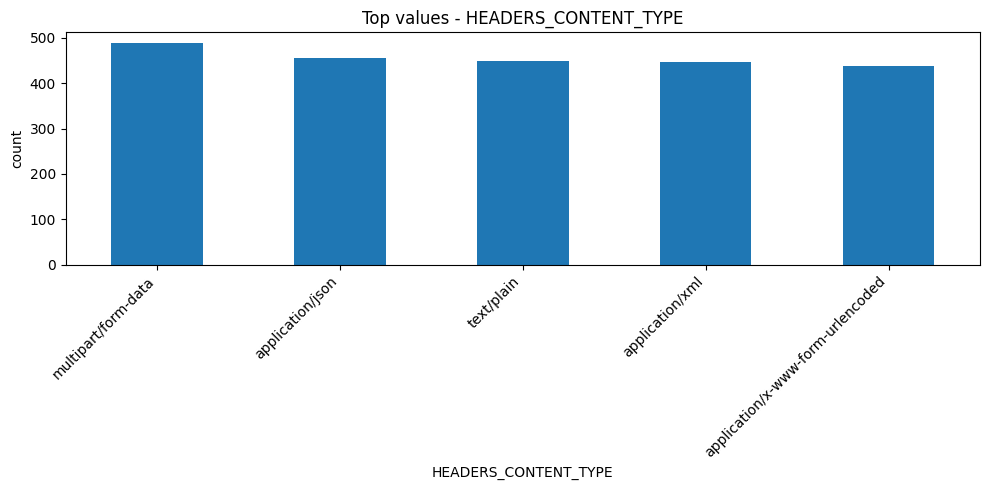

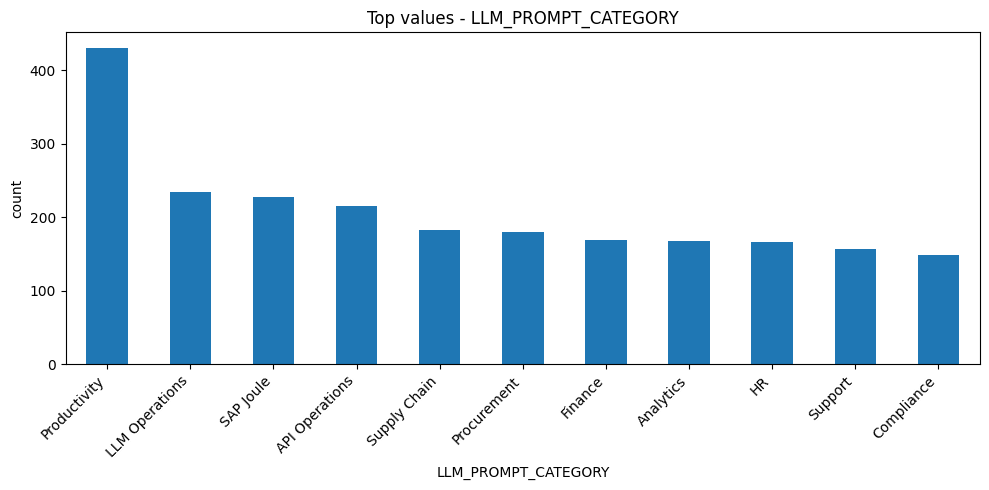

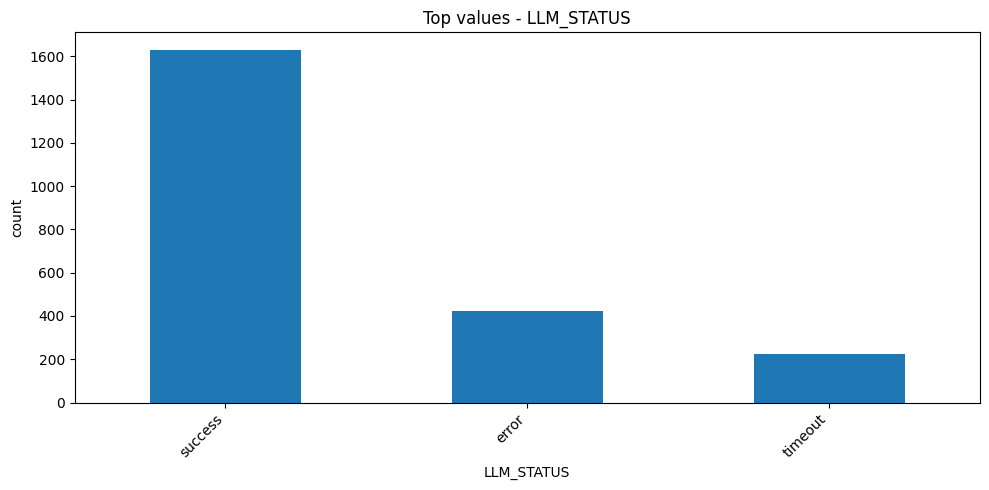

In [93]:
for col in cat_cols:
    counts = df_llm[col].dropna().astype(str).value_counts().head(15)

    if counts.empty:
        print(f"No hay valores válidos para graficar en {col}")
        continue

    plt.figure(figsize=(10, 5))
    counts.plot(kind="bar")

    plt.title(f"Top values - {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

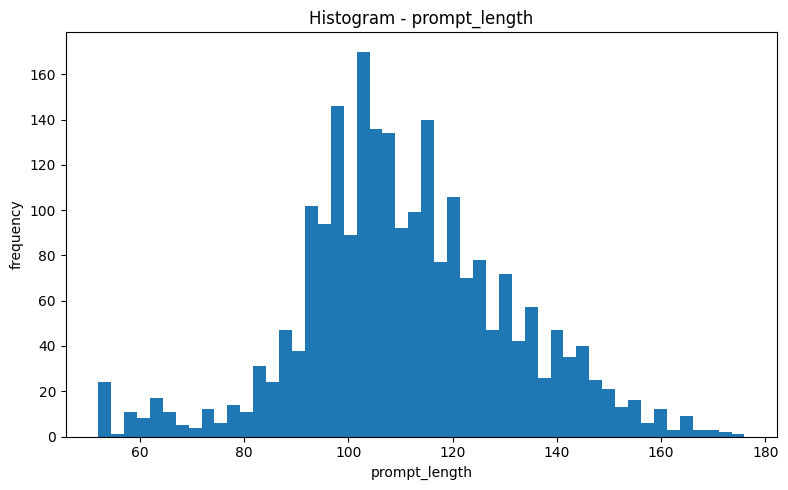

In [94]:
for col in num_cols:
    plt.figure(figsize=(8,5))
    
    df_llm[col].dropna().plot(kind="hist", bins=50)
    
    plt.title(f"Histogram - {col}")
    plt.xlabel(col)
    plt.ylabel("frequency")
    
    plt.tight_layout()
    plt.show()

In [95]:
df_llm[df_llm['LLM_STATUS'] == "error"]

,EVENT_HASH,TIMESTAMP,SOURCE_IP,LOCATION,SERVICE_ID,LLM_PROVIDER,LLM_PROMPT,LLM_TOTAL_TOKENS,LLM_COST_USD,LLM_RESPONSE_TIME_MS,...,is_weekend,minute_window,requests_per_minute,errors_per_minute,avg_latency_per_minute,tokens_per_minute,prompt_length,token_density,latency_per_token,cost_intensity
5,e57dfbfcc33c36ab0e20fb2e84c9e6e9ce475442d1417214b075df35bcb4fed9,2026-05-04 09:59:49,Unknown,Netherlands | Eemshaven,NaN,Mistral,Review safety stock levels for sap-fiori-launchpad in Netherlands | Eemshaven and adjust based on updated service-level targets.,2205,0.000661,2123,...,0,2026-05-04 09:59:00,33,10,11280.909091,58839,128,17.226562,0.962812,2.997732e-07
8,67e8eec504f3ff88868693ab5e645b1c206290eb852bf1fa87fec71ad7f49bac,2026-05-04 09:59:43,Unknown,Australia | Victoria,NaN,Google,Summarise the decision made in the sap-s4hana-finance review meeting and document the rationale.,1129,0.009032,2827,...,0,2026-05-04 09:59:00,33,10,11280.909091,58839,96,11.760417,2.503986,8.000000e-06
9,375de5f1fa1db3fc07b915753cd0078d3240144d242d47e8d8becafd13ed6cd4,2026-05-04 09:59:41,Unknown,Japan | Tokyo,NaN,Google,Draft a request for proposal for the sap-data-sphere replacement project targeting vendors in Japan | Tokyo.,1281,0.000512,2500,...,0,2026-05-04 09:59:00,33,10,11280.909091,58839,108,11.861111,1.951600,3.996877e-07
11,ea4964a2cf181e62b02f88ac07f72727d8948f2f100c7cb30a0d8c6187553a7c,2026-05-04 09:59:37,Unknown,Australia | Sydney (2),NaN,OpenAI,Have SAP Joule draft an approval request for the budget exception in sap-successfactors.,1889,0.056670,2738,...,0,2026-05-04 09:59:00,33,10,11280.909091,58839,88,21.465909,1.449444,3.000000e-05
24,41195b479b882f90ef1a815d776475a49b9d46d1cc1b4b471afc5adb353d10de,2026-05-04 09:59:16,Unknown,Saudi Arabia,NaN,OpenAI,Have SAP Joule draft an approval request for the budget exception in sap-ariba.,991,0.019820,1437,...,0,2026-05-04 09:59:00,33,10,11280.909091,58839,79,12.544304,1.450050,2.000000e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,80f71dad0e2c007264426b9f53735f0cb0562e378a10fbf6332966022eaca35b,2026-05-04 09:01:12,NaN,Switzerland | Zurich,NaN,OpenAI,Generate a compliance checklist for sap-s4hana-finance month-end close.,941,0.009410,1411,...,0,2026-05-04 09:01:00,40,11,6549.375000,65212,71,13.253521,1.499469,1.000000e-05
2236,c84129de11aec935319c346f586ad366cc9ba07b008bcf061282570a3f2b2310,2026-05-04 09:01:11,NaN,Austria | Vienna,NaN,Anthropic,"Generate a response quality report for the sap-ariba LLM pipeline in Austria | Vienna covering accuracy, relevance, and tone metrics.",1011,0.000253,2896,...,0,2026-05-04 09:01:00,40,11,6549.375000,65212,133,7.601504,2.864491,2.502473e-07
2251,4d2a4a474876e12c48e42bda40282bf7af2f09510bafab5ff818aa9ebf5f0677,2026-05-04 09:00:35,NaN,South Africa | Cape Town,NaN,Anthropic,Draft a contract renewal recommendation for vendor GreenField Supplies expiring this quarter.,709,0.002836,2525,...,0,2026-05-04 09:00:00,35,6,9207.057143,59315,93,7.623656,3.561354,4.000000e-06
2271,b8d20a794748c770dfae3b00c80f275b3659b6250aafc28f4e5322d0762db572,2026-05-04 09:00:17,NaN,Brazil | São Paulo,NaN,OpenAI,Generate a mock server specification for the sap-successfactors API so Brazil | São Paulo teams can develop against it without hitting production.,685,0.006850,1318,...,0,2026-05-04 09:00:00,35,6,9207.057143,59315,146,4.691781,1.924088,1.000000e-05


**Variable Binaria**

In [96]:
df_llm["is_error"] = df_llm["LLM_STATUS"].str.contains("error", case=False, na=False)

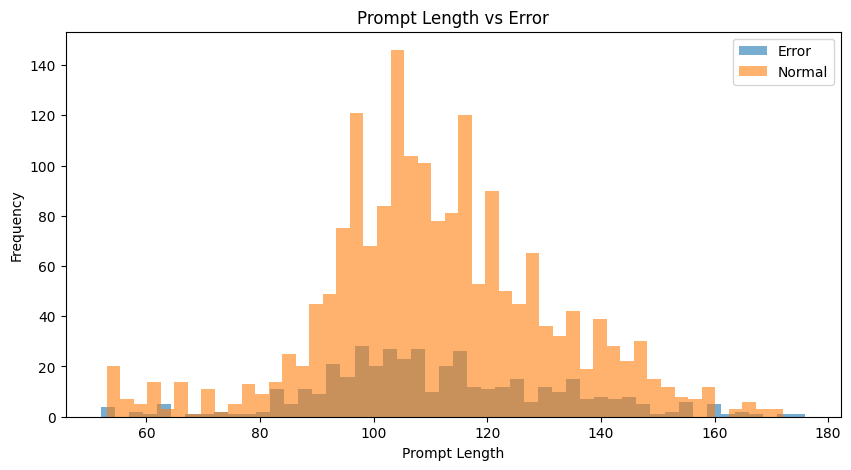

In [97]:
plt.figure(figsize=(10,5))

plt.hist(df_llm[df_llm["is_error"]]["prompt_length"], bins=50, alpha=0.6, label="Error")
plt.hist(df_llm[~df_llm["is_error"]]["prompt_length"], bins=50, alpha=0.6, label="Normal")

plt.xlabel("Prompt Length")
plt.ylabel("Frequency")
plt.title("Prompt Length vs Error")
plt.legend()

plt.show()

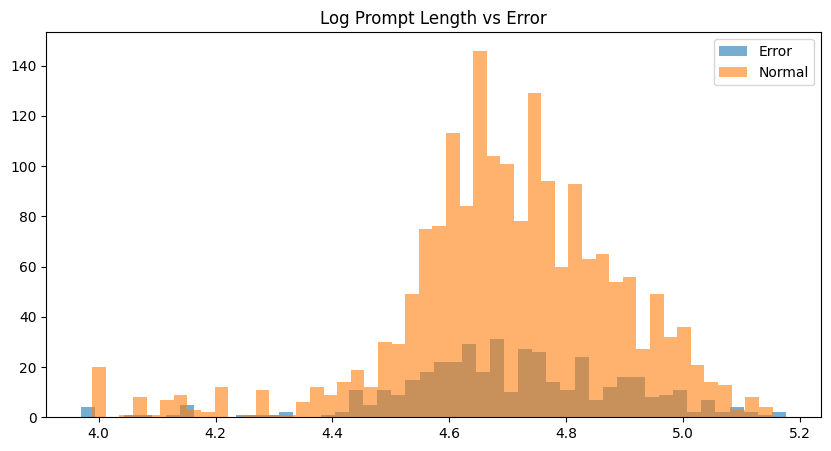

In [98]:
plt.figure(figsize=(10,5))

plt.hist(np.log1p(df_llm[df_llm["is_error"]]["prompt_length"]), bins=50, alpha=0.6, label="Error")
plt.hist(np.log1p(df_llm[~df_llm["is_error"]]["prompt_length"]), bins=50, alpha=0.6, label="Normal")

plt.title("Log Prompt Length vs Error")
plt.legend()

plt.show()

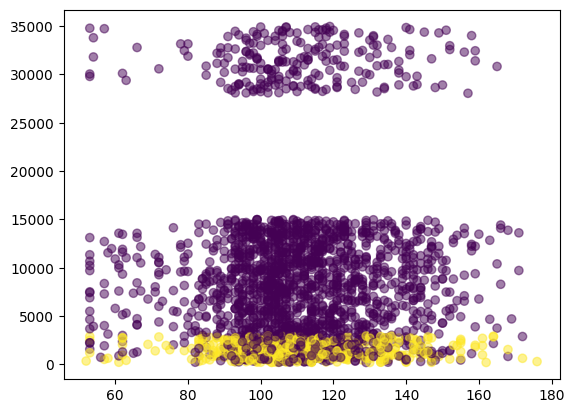

In [99]:
plt.scatter(
    df_llm["prompt_length"],
    df_llm["LLM_RESPONSE_TIME_MS"],
    c=df_llm["is_error"].astype(int),
    alpha=0.5
)


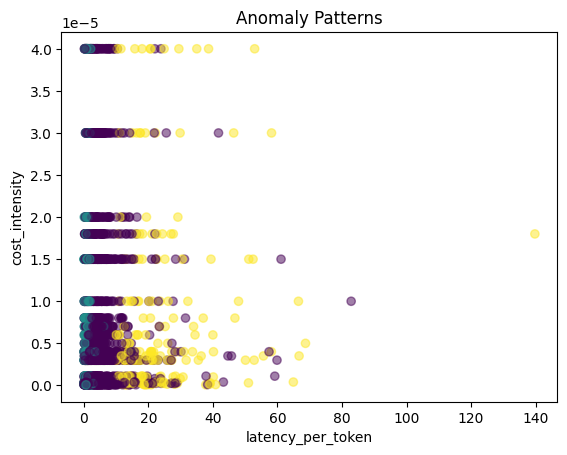

In [100]:
plt.scatter(
    df_llm["latency_per_token"],
    df_llm["cost_intensity"],
    c=df_llm["LLM_STATUS"].map({"success":0, "error":1, "timeout":2}),
    alpha=0.5
)

plt.xlabel("latency_per_token")
plt.ylabel("cost_intensity")
plt.title("Anomaly Patterns")
plt.show()

In [101]:
def plot_error_rate(df, col, top_n=15):
    # calcular tasa de error por categoría
    temp = df.groupby(col)["is_error"].mean().sort_values(ascending=False).head(top_n)
    
    plt.figure(figsize=(10,5))
    temp.plot(kind="bar")
    
    plt.title(f"Error Rate by {col}")
    plt.ylabel("Error Rate")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

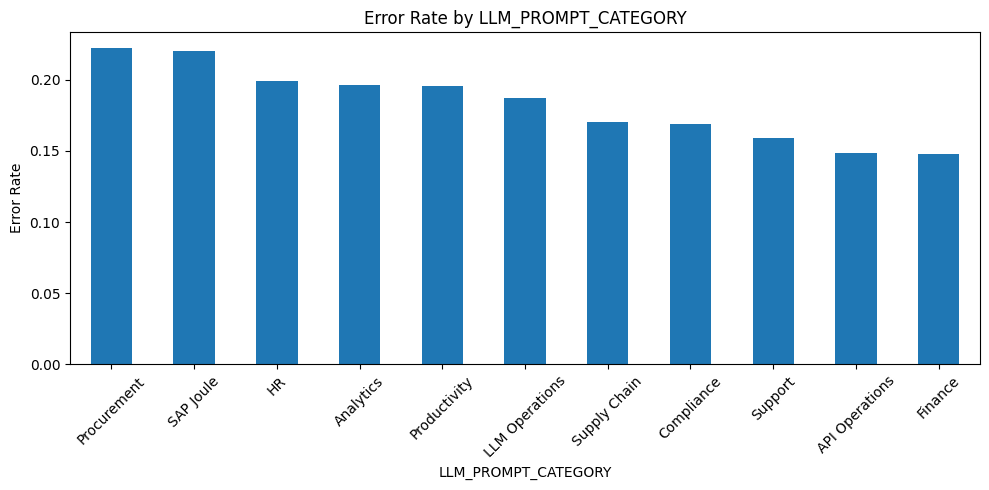

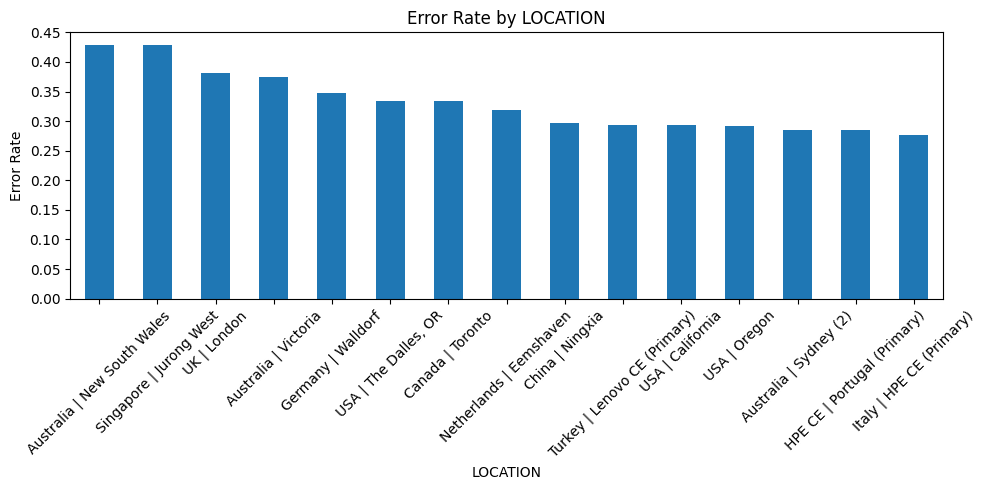

In [102]:
plot_error_rate(df_llm, "LLM_PROMPT_CATEGORY")
plot_error_rate(df_llm, "LOCATION")


In [103]:
pd.set_option('display.max_colwidth', None)

In [104]:
df_llm.shape

(2277, 32)

In [105]:
for cat in df_llm["LLM_STATUS"].unique():
    if cat != "success": 
        print(f"\n=== {cat} ===")
        print(df_llm[df_llm["LLM_STATUS"] == cat]["LLM_PROMPT"].head(20))
    else: 
        pass



=== timeout ===
0                                        Perform a cohort analysis of sap-s4hana-sales users in South Africa | Johannesburg (2) who onboarded in Q3.
12                     Analyse procurement spend for sap-intelligent-rpa in Hungary | HPE CE (Primary) during Q3 and identify savings opportunities.
14                 Draft a weekly status update for the sap-s4hana-sales project in USA | Colorado Springs, CO (2) suitable for senior stakeholders.
15                                              Create a slide outline for a presentation on sap-successfactors performance in Japan | Osaka for Q1.
26                                        Have SAP Joule propose a budget reallocation for sap-btp-cf to cover the Q1 shortfall in USA | California.
38                                                     Analyse the budget variance for sap-successfactors in Q2 and suggest cost-reduction measures.
39                                                   Review the API security posture of s

In [106]:
df_llm["LLM_PROMPT"].value_counts()

LLM_PROMPT
Extract all action items from the following discussion about sap-s4hana-sales and assign owners where mentioned.                                      5
Suggest prompt optimisations to reduce token usage for the sap-successfactors inference pipeline.                                                     4
Explain the technical jargon in the following sap-successfactors documentation in simple terms.                                                       4
Identify latency bottlenecks in the sap-intelligent-rpa LLM inference pipeline and suggest optimisation techniques.                                   4
Explain the anomaly in the financial forecast for Q1.                                                                                                 4
                                                                                                                                                     ..
Generate a mock server specification for the sap-successfactors API so Brazil

In [107]:
df_llm[df_llm["is_error"]]["LLM_PROMPT"].value_counts().head(10)

LLM_PROMPT
Have SAP Joule draft an approval request for the budget exception in sap-successfactors.                                       2
Audit the sap-analytics-cloud prompt templates for potential injection vulnerabilities and recommend sanitisation measures.    2
Identify unreconciled transactions in sap-data-sphere for Q1 and suggest resolution steps.                                     2
Rewrite the following message about sap-s4hana-sales to be clearer and more concise.                                           2
Review the API security posture of sap-intelligent-rpa and flag any authentication or authorisation gaps.                      2
Summarise LLM API token consumption for sap-btp-cf over the past 30 days and highlight cost drivers.                           2
Given the following list of open tasks for sap-concur, suggest a priority order based on urgency and impact.                   2
Rewrite the following message about sap-fiori-launchpad to be clearer and more concise

In [108]:
df_llm.groupby("LLM_PROMPT_CATEGORY")["prompt_length"].mean().sort_values(ascending=False)

LLM_PROMPT_CATEGORY
API Operations    121.144186
LLM Operations    117.089362
Compliance        115.344595
Supply Chain      114.851648
SAP Joule         111.590308
Productivity      109.960465
HR                109.801205
Support           108.796178
Procurement       106.555556
Analytics         102.464286
Finance           102.035503
Name: prompt_length, dtype: float64

In [109]:
def classify_prompt(prompt):
    if pd.isna(prompt):
        return "unknown"
    
    prompt = prompt.lower()
    
    if any(x in prompt for x in ["summarise", "summarize"]):
        return "summarization"
    if any(x in prompt for x in ["generate", "draft", "write"]):
        return "generation"
    if any(x in prompt for x in ["forecast", "predict", "benchmark"]):
        return "analysis"
    if any(x in prompt for x in ["error", "failure"]):
        return "system_task"
    
    return "other"

df_llm["task_type"] = df_llm["LLM_PROMPT"].apply(classify_prompt)


In [110]:
df_llm.groupby("task_type")["is_error"].mean().sort_values(ascending=False) * 100

task_type
summarization    21.395349
generation       18.842730
other            18.512257
system_task      17.894737
analysis         11.818182
Name: is_error, dtype: float64

## Modelo

In [111]:
df_normal = df_llm[df_llm["LLM_STATUS"] == "success"]

De las 34 instancias marcadas como anómalas, la mayoría corresponden a fallas reales (timeouts y algunos errores), lo cual es positivo, pero al mismo tiempo está ignorando la gran mayoría de errores totales (solo detecta ~2% de errores y ~24% de timeouts), lo que indica que muchos fallos ocurren dentro de patrones “normales” aprendidos por el modelo; en otras palabras, no todo error es una anomalía y tu modelo está aprendiendo eso correctamente. 


In [112]:
num_features = [
    "LLM_TOTAL_TOKENS",
    "LLM_COST_USD",
    "LLM_RESPONSE_TIME_MS",
    "HTTP_STATUS_CODE",
    "prompt_length",
    "latency_per_token",
    "cost_intensity",
    "token_density",

    # temporales
    "hour",
    "day_of_week",
    "day_of_month",
    "month",
    "is_night",
    "is_weekend",

    # tráfico por ventana
    "requests_per_minute",
    "errors_per_minute",
    "avg_latency_per_minute",
    "tokens_per_minute"
]

num_features = [c for c in num_features if c in df_llm.columns]

In [113]:
cat_features = [
    "LOCATION",
    "LLM_PROVIDER",
    "LLM_PROMPT_CATEGORY",
    "LLM_STATUS",
    "task_type"
]

cat_features = [c for c in cat_features if c in df_llm.columns]

# Quitar columnas categóricas vacías
cat_features = [
    c for c in cat_features
    if df_llm[c].notna().sum() > 0
]

cat_features

['LOCATION', 'LLM_PROVIDER', 'LLM_PROMPT_CATEGORY', 'LLM_STATUS', 'task_type']

In [114]:
if (
    "HEADERS_CONTENT_TYPE" in df_llm.columns
    and df_llm["HEADERS_CONTENT_TYPE"].notna().sum() > 0
):
    df_llm["HEADERS_CONTENT_TYPE"] = (
        df_llm["HEADERS_CONTENT_TYPE"]
        .astype(str)
        .str.split(";")
        .str[0]
    )
else:
    print("HEADERS_CONTENT_TYPE está vacía; se omite esta limpieza.")

In [115]:
df_num = df_llm[num_features].copy()

for col in num_features:
    df_num[col] = pd.to_numeric(df_num[col], errors="coerce")

df_cat = pd.get_dummies(
    df_llm[cat_features].fillna("Unknown").astype(str),
    drop_first=True
)

X = pd.concat([df_num, df_cat], axis=1)

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True)).fillna(0)

print("Shape X:", X.shape)
print("Filas df_llm:", df_llm.shape[0])
print("Features usadas:", X.shape[1])

Shape X: (2277, 146)
Filas df_llm: 2277
Features usadas: 146


In [116]:
from sklearn.ensemble import IsolationForest

print("Shape X:", X.shape)
print("Shape df_llm:", df_llm.shape)

if X.empty:
    raise ValueError("X está vacío. No se puede entrenar el modelo.")

if "LLM_STATUS" in df_llm.columns:
    train_idx = df_llm[df_llm["LLM_STATUS"].eq("success")].index
    train_idx = X.index.intersection(train_idx)
    X_train = X.loc[train_idx]

    if X_train.empty:
        print("No hay registros success suficientes. Entrenando con todo X.")
        X_train = X.copy()
else:
    X_train = X.copy()

print("Shape X_train:", X_train.shape)

model = IsolationForest(
    contamination=0.05,
    n_estimators=200,
    random_state=42
)

model.fit(X_train)

preds = model.predict(X)
scores = model.decision_function(X)

df_llm["anomaly_isof"] = preds
df_llm["anomaly_score_isof"] = scores
df_llm["is_anomaly_isof"] = (df_llm["anomaly_isof"] == -1).astype(int)

df_llm["is_anomaly_isof"].value_counts()

Shape X: (2277, 146)
Shape df_llm: (2277, 33)
Shape X_train: (1629, 146)


is_anomaly_isof
0    2121
1     156
Name: count, dtype: int64

In [117]:
pd.crosstab(df_llm["anomaly_isof"], df_llm["LLM_STATUS"])

LLM_STATUS,error,success,timeout
anomaly_isof,,,
-1,27,82,47
1,395,1547,179


In [118]:
df_llm.loc[df_llm['anomaly_isof'] == -1,
           ["LLM_PROMPT", "anomaly_isof"]]

,LLM_PROMPT,anomaly_isof
34,Summarise the tax provision calculation for sap-analytics-cloud in Malaysia | Cyberjaya for Q4.,-1
56,Provide a demand forecast for sap-intelligent-rpa products in Hungary | HPE CE (Primary) for the next quarter.,-1
63,"A critical component shortage has been flagged for sap-data-sphere in USA | Ashburn, VA. Draft an escalation plan and identify alternative suppliers.",-1
75,Summarise exit interview themes for employees who left sap-intelligent-rpa in China | North 3 during Q3 and suggest retention actions.,-1
76,Summarise the tax provision calculation for sap-analytics-cloud in USA | Ohio for Q4.,-1
...,...,...
2210,Triage the LLM inference error WORK_PROCESS_UNAVAILABLE returned by sap-analytics-cloud and recommend a resolution.,-1
2212,Identify unreconciled transactions in sap-successfactors for Q1 and suggest resolution steps.,-1
2253,Draft a change request for the proposed configuration update to sap-s4hana-sales in USA | Washington DC.,-1
2270,Ask SAP Joule to summarise the current status of all open workflows in sap-fiori-launchpad for Spain | Madrid.,-1


## SVM - One Class

In [119]:
# split: entrena solo con normales, respetando el índice de X
idx_train = df_llm.loc[X.index, "LLM_STATUS"].eq("success")
X_train = X.loc[idx_train]
X_test  = X.copy()  # evalúas en todo X válido

In [120]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [121]:
from sklearn.svm import OneClassSVM

ocsvm = OneClassSVM(kernel="rbf", gamma="scale", nu=0.05)  # nu≈contamination
ocsvm.fit(X_train_s)

pred_svm = ocsvm.predict(X_test_s)   # -1 anomalía, 1 normal

df_llm["anom_svm"] = np.nan
df_llm.loc[X_test.index, "anom_svm"] = pred_svm
df_llm["anom_svm"] = df_llm["anom_svm"].astype("Int64")


## TDA

In [122]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# reducción: no pedir más componentes que features o muestras disponibles
n_components = min(10, X_scaled.shape[1], max(1, X_scaled.shape[0] - 1))
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [123]:
from ripser import ripser
import numpy as np

# separar grupos respetando el índice válido de X/X_pca
status_valid = df_llm.loc[X.index, "LLM_STATUS"]
idx_success = status_valid.eq("success").to_numpy()
idx_fail = status_valid.isin(["error", "timeout"]).to_numpy()

X_success = X_pca[idx_success]
X_fail = X_pca[idx_fail]

# calcular diagramas solo si hay puntos suficientes
dgms_success = ripser(X_success, maxdim=1)["dgms"] if len(X_success) > 1 else []
dgms_fail = ripser(X_fail, maxdim=1)["dgms"] if len(X_fail) > 1 else []


In [124]:
def topo_features(diagrams):
    features = []
    
    for dim in diagrams:
        lifetimes = dim[:, 1] - dim[:, 0]
        lifetimes = lifetimes[np.isfinite(lifetimes)]
        
        if len(lifetimes) == 0:
            features.extend([0, 0, 0])
        else:
            features.extend([
                lifetimes.mean(),
                lifetimes.std(),
                lifetimes.max()
            ])
    
    return features

feat_success = topo_features(dgms_success)
feat_fail = topo_features(dgms_fail)


In [125]:
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=30).fit(X_pca)
distances, indices = nbrs.kneighbors(X_pca)

topo_features_list = []

for idx in indices:
    subset = X_pca[idx]
    dgms = ripser(subset, maxdim=1)["dgms"]
    topo_features_list.append(topo_features(dgms))

import pandas as pd
df_topo = pd.DataFrame(topo_features_list, columns=[
    "h0_mean", "h0_std", "h0_max",
    "h1_mean", "h1_std", "h1_max"
])

In [126]:
X_tda = pd.concat([
    X.reset_index(drop=True),
    df_topo
], axis=1).dropna()

In [127]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import IsolationForest
from ripser import ripser

# =========================
# 1. PREPARACIÓN
# =========================
df_model = df_llm.loc[X.index].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_components = min(10, X_scaled.shape[1], max(1, X_scaled.shape[0] - 1))
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# =========================
# 2. TDA LOCAL
# =========================
def topo_features(diagrams):
    features = []
    for dim in diagrams:
        lifetimes = dim[:, 1] - dim[:, 0]
        lifetimes = lifetimes[np.isfinite(lifetimes)]
        
        if len(lifetimes) == 0:
            features.extend([0, 0, 0])
        else:
            features.extend([lifetimes.mean(), lifetimes.std(), lifetimes.max()])
    return features

n_neighbors = min(30, len(X_pca))
nbrs = NearestNeighbors(n_neighbors=n_neighbors).fit(X_pca)
_, indices = nbrs.kneighbors(X_pca)

topo_list = []
for idx in indices:
    subset = X_pca[idx]
    dgms = ripser(subset, maxdim=1)["dgms"]
    topo_list.append(topo_features(dgms))

df_topo = pd.DataFrame(topo_list, index=X.index, columns=[
    "h0_mean", "h0_std", "h0_max",
    "h1_mean", "h1_std", "h1_max"
])

# =========================
# 3. COMBINAR FEATURES
# =========================
X_tda = pd.concat([X, df_topo], axis=1).replace([np.inf, -np.inf], np.nan).dropna()
df_aligned = df_llm.loc[X_tda.index].copy()

# =========================
# 4. TRAIN solo con success
# =========================
idx_train = df_aligned["LLM_STATUS"].eq("success")
X_train_tda = X_tda.loc[idx_train]

model = IsolationForest(
    contamination=0.05,
    n_estimators=200,
    random_state=42
)
model.fit(X_train_tda)

# =========================
# 5. PREDICCIÓN
# =========================
df_llm["anomaly_tda"] = np.nan
preds = model.predict(X_tda)
df_llm.loc[X_tda.index, "anomaly_tda"] = preds
df_llm["anomaly_tda"] = df_llm["anomaly_tda"].astype("Int64")


In [128]:
groups = {
    "success": df_llm.loc[X.index, "LLM_STATUS"].eq("success").to_numpy(),
    "error": df_llm.loc[X.index, "LLM_STATUS"].eq("error").to_numpy(),
    "timeout": df_llm.loc[X.index, "LLM_STATUS"].eq("timeout").to_numpy()
}


In [129]:
from ripser import ripser

diagrams_all = {}

for name, mask in groups.items():
    X_group = X_pca[mask]
    
    if len(X_group) > 500:
        X_group = X_group[:500]
    
    if len(X_group) > 1:
        dgms = ripser(X_group, maxdim=1)["dgms"]
        diagrams_all[name] = dgms
    else:
        print(f"{name}: no hay suficientes puntos para TDA")


In [130]:
all_h1 = np.vstack([
    dgms[1] for dgms in diagrams_all.values()
    if len(dgms) > 1 and len(dgms[1]) > 0
])

birth_min, death_max = all_h1.min(), all_h1.max()


In [131]:
from persim import PersistenceImager

pimgr = PersistenceImager(
    pixel_size=0.1,
    birth_range=(birth_min, death_max),
    pers_range=(0, death_max - birth_min)
)


In [132]:
images = {}

for name, dgms in diagrams_all.items():
    img = pimgr.transform(dgms[1])
    images[name] = img


In [133]:
diff_error = images["error"] - images["success"]
diff_timeout = images["timeout"] - images["success"]


In [134]:
# revisa cuántos puntos hay en cada dimensión
for name, dgms in diagrams_all.items():
    print(name, "H0:", len(dgms[0]), "H1:", len(dgms[1]))


success H0: 500 H1: 487
error H0: 422 H1: 401
timeout H0: 226 H1: 197


In [135]:
dim_to_use = 1 if all(len(dgms[1]) > 0 for dgms in diagrams_all.values()) else 0
print("Usando dimensión:", dim_to_use)


Usando dimensión: 1


In [136]:
import numpy as np
from persim import PersistenceImager

all_pts = np.vstack([
    dgms[dim_to_use] for dgms in diagrams_all.values()
    if len(dgms[dim_to_use]) > 0
])

birth_min, death_max = all_pts.min(), all_pts.max()

pimgr = PersistenceImager(
    pixel_size=0.1,
    birth_range=(birth_min, death_max),
    pers_range=(0, death_max - birth_min)
)


In [137]:
images = {}

for name, dgms in diagrams_all.items():
    if len(dgms[dim_to_use]) == 0:
        print(f"{name} vacío, saltando")
        continue
    
    img = pimgr.transform(dgms[dim_to_use])
    images[name] = img
    print(name, img.shape, "min/max:", img.min(), img.max())


success (36, 36) min/max: 0.00010338413480778777 0.14947935879258675
error (36, 36) min/max: 0.0001004997004317681 0.12511985003254628
timeout (36, 36) min/max: 9.842196101489303e-05 0.06524859726701217


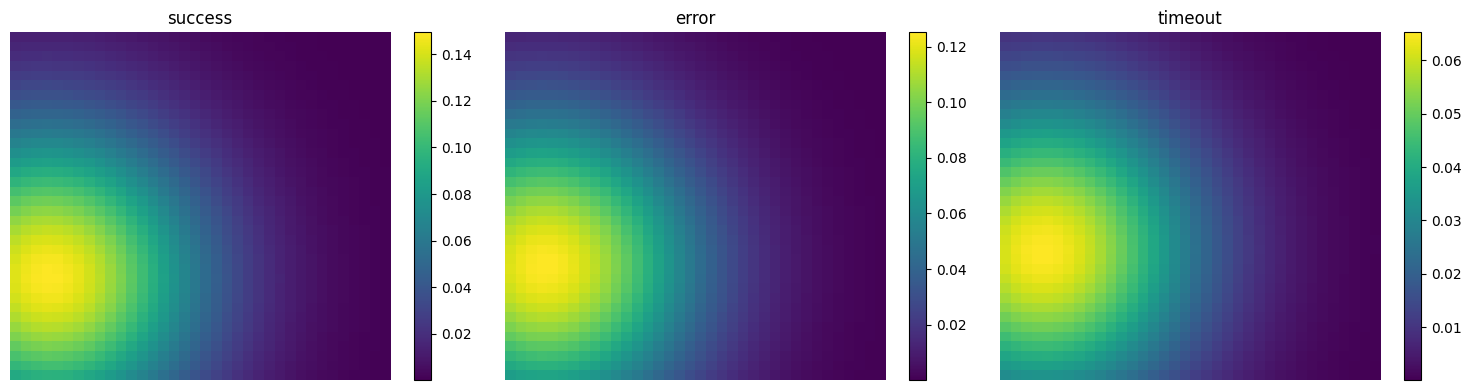

In [138]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 4))

if len(images) == 1:
    axes = [axes]

for ax, (name, img) in zip(axes, images.items()):
    im = ax.imshow(img, origin="lower", aspect="auto")
    ax.set_title(name)
    ax.axis("off")
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


## Autoencoder

In [139]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Arquitectura del Autoencoder
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 16),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Instanciar modelo
input_dim = X_train_s.shape[1]
ae_model = Autoencoder(input_dim)

# Convertir arrays de Numpy a Tensores de PyTorch
X_train_tensor = torch.tensor(X_train_s, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_s, dtype=torch.float32)

# Crear DataLoader para manejar batches
dataset = TensorDataset(X_train_tensor, X_train_tensor)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

optimizer = optim.Adam(ae_model.parameters())
criterion = nn.MSELoss()

epochs = 20
ae_model.train()

for epoch in range(epochs):
    for batch_x, batch_y in dataloader:
        optimizer.zero_grad()
        outputs = ae_model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

# Evaluación y cálculo del error de reconstrucción
ae_model.eval()
with torch.no_grad():
    recon_test = ae_model(X_test_tensor)
    mse = ((X_test_tensor - recon_test) ** 2).mean(dim=1).numpy()
    
    recon_train = ae_model(X_train_tensor)
    train_mse = ((X_train_tensor - recon_train) ** 2).mean(dim=1).numpy()
    thr = np.percentile(train_mse, 95)

# Asignar anomalías respetando índice de X_test
df_llm["anom_ae"] = np.nan
df_llm.loc[X_test.index, "anom_ae"] = np.where(mse > thr, -1, 1)
df_llm["anom_ae"] = df_llm["anom_ae"].astype("Int64")


In [140]:
from ripser import ripser
from sklearn.decomposition import PCA

# reduce dimensionalidad para TDA
X_tda = PCA(n_components=10).fit_transform(X_test_s)

diagrams = ripser(X_tda, maxdim=1)["dgms"]
# inspecciona diagramas de persistencia (H0, H1)


In [141]:
columnas_preds = ['anomaly_isof', 'anom_svm', 'anom_ae', 'anomaly_tda']


In [142]:
print(df_llm[columnas_preds].corr())

              anomaly_isof  anom_svm   anom_ae  anomaly_tda
anomaly_isof      1.000000  0.256852  0.128963     0.405091
anom_svm          0.256852  1.000000  0.598266     0.322207
anom_ae           0.128963  0.598266  1.000000     0.225549
anomaly_tda       0.405091  0.322207  0.225549     1.000000


Se destaca una correlación máxima de 0.60 entre el Autoencoder y el SVM que sugiere cierta redundancia en la captura de anomalías por distancia espacial. 
Por otro lado, las bajas correlaciones del Isolation Forest y TDA confirman que estos capturan dimensiones ortogonales de aislamiento y estructura topológica, respectivamente. 

In [143]:
df_llm['votos_anomalia'] = (df_llm[columnas_preds] == -1).sum(axis=1)

In [144]:
pd.set_option('display.max_colwidth', None)

# Filtrar casos donde hay conflicto (ej. exactamente 2 modelos lo marcan como anomalía)
casos_en_conflicto = df_llm[df_llm['votos_anomalia'] == 2]
casos_en_conflicto[['LLM_PROMPT'] + columnas_preds].head(10)


,LLM_PROMPT,anomaly_isof,anom_svm,anom_ae,anomaly_tda
8,Summarise the decision made in the sap-s4hana-finance review meeting and document the rationale.,1,-1,-1,1
11,Have SAP Joule draft an approval request for the budget exception in sap-successfactors.,1,-1,-1,1
26,Have SAP Joule propose a budget reallocation for sap-btp-cf to cover the Q1 shortfall in USA | California.,1,-1,-1,1
83,Generate a compliance checklist for sap-s4hana-sales month-end close.,1,-1,-1,1
86,Write a welcome email for a new team member joining the sap-concur project in Australia | Victoria.,1,-1,-1,1
92,"Draft a project charter for the sap-s4hana-finance initiative in Australia | Sydney (2) including scope, objectives, stakeholders, and success criteria.",1,1,-1,-1
108,Summarize the latest sales report for region Finland | Hamina.,-1,-1,1,1
118,"Analyse leave utilisation patterns for the sap-concur team in USA | The Dalles, OR during Q1 and flag any compliance concerns.",1,-1,-1,1
127,Interpret the A/B test results for the sap-successfactors feature rollout in Denmark | HPE CE (Primary) and recommend whether to proceed with full deployment.,1,-1,-1,1
128,Suggest prompt optimisations to reduce token usage for the sap-ariba inference pipeline.,1,-1,-1,1


In [145]:
anomalias_consenso = df_llm[(df_llm['anomaly_isof'] == -1) & 
                            (df_llm['anom_svm'] == -1) & 
                            (df_llm['anom_ae'] == -1) &
                             (df_llm['anomaly_tda'] == -1)]

# 2. Calculamos el porcentaje
porcentaje = (len(anomalias_consenso) / len(df_llm)) * 100

print(f"Porcentaje de anomalías detectadas por los 4 modelos: {porcentaje:.2f}%")


Porcentaje de anomalías detectadas por los 4 modelos: 1.10%


In [146]:
len(anomalias_consenso)

25

El mayor concenso entre los modelos está entre el svm y el autoencoder

In [147]:
anomalias_consenso = df_llm[#(df_llm['anomaly_isof'] == -1) & 
                            (df_llm['anom_svm'] == -1) &
                            (df_llm['anom_ae'] == -1) ]

# 2. Calculamos el porcentaje
porcentaje = (len(anomalias_consenso) / len(df_llm)) * 100

print(f"Porcentaje de anomalías detectadas por los 2 modelos: {porcentaje:.2f}%")

Porcentaje de anomalías detectadas por los 2 modelos: 7.64%


In [148]:
len(anomalias_consenso)

174

In [149]:
df_llm.columns

Index(['EVENT_HASH', 'TIMESTAMP', 'SOURCE_IP', 'LOCATION', 'SERVICE_ID',
       'LLM_PROVIDER', 'LLM_PROMPT', 'LLM_TOTAL_TOKENS', 'LLM_COST_USD',
       'LLM_RESPONSE_TIME_MS', 'HTTP_STATUS_CODE', 'ANOMALY_SCORE', 'LABEL',
       'HEADERS_CONTENT_TYPE', 'LLM_PROMPT_CATEGORY', 'LLM_STATUS', 'hour',
       'day_of_week', 'day_of_month', 'month', 'is_night', 'is_weekend',
       'minute_window', 'requests_per_minute', 'errors_per_minute',
       'avg_latency_per_minute', 'tokens_per_minute', 'prompt_length',
       'token_density', 'latency_per_token', 'cost_intensity', 'is_error',
       'task_type', 'anomaly_isof', 'anomaly_score_isof', 'is_anomaly_isof',
       'anom_svm', 'anomaly_tda', 'anom_ae', 'votos_anomalia'],
      dtype='str')

# Ensamble

In [154]:
# =========================
# ENSEMBLE POR VOTACIÓN
# =========================

anomaly_cols = [
    "anomaly_isof",
    "anom_svm",
    "anom_ae",
    "anomaly_tda"
]

# Asegurar valores 0/1
for col in anomaly_cols:
    df_llm[col] = df_llm[col].fillna(0).astype(int)

# Número de modelos que votaron anomalía
df_llm["anomaly_votes"] = df_llm[anomaly_cols].sum(axis=1)

# Regla de severidad
df_llm["severity"] = pd.cut(
    df_llm["anomaly_votes"],
    bins=[-1, 0, 1, 2, 4],
    labels=["Normal", "Low", "Medium", "High"]
)

# Anomalía de alta confianza
df_llm["is_high_confidence_anomaly"] = (
    df_llm["anomaly_votes"] >= 3
).astype(int)

# Anomalía por consenso total de los 4 modelos
df_llm["is_full_consensus_anomaly"] = (
    df_llm["anomaly_votes"] == 4
).astype(int)

df_llm[[
    "anomaly_votes",
    "severity",
    "is_high_confidence_anomaly",
    "is_full_consensus_anomaly"
]].head()

,anomaly_votes,severity,is_high_confidence_anomaly,is_full_consensus_anomaly
0,2,Medium,0,0
1,4,High,1,1
2,4,High,1,1
3,4,High,1,1
4,4,High,1,1


In [155]:
# =========================
# RESUMEN DEL ENSEMBLE
# =========================

total = len(df_llm)

summary_ensemble = pd.DataFrame({
    "metric": [
        "Total events",
        "Low severity anomalies",
        "Medium severity anomalies",
        "High severity anomalies",
        "Full consensus anomalies"
    ],
    "count": [
        total,
        (df_llm["severity"] == "Low").sum(),
        (df_llm["severity"] == "Medium").sum(),
        (df_llm["severity"] == "High").sum(),
        df_llm["is_full_consensus_anomaly"].sum()
    ]
})

summary_ensemble["percentage"] = (
    summary_ensemble["count"] / total * 100
).round(2)

summary_ensemble

,metric,count,percentage
0,Total events,2277,100.00
1,Low severity anomalies,0,0.00
2,Medium severity anomalies,248,10.89
3,High severity anomalies,1776,78.00
4,Full consensus anomalies,1776,78.00


In [156]:
severity_distribution = (
    df_llm["severity"]
    .value_counts()
    .reindex(["Normal", "Low", "Medium", "High"])
    .fillna(0)
    .astype(int)
)

severity_distribution

severity
Normal     167
Low          0
Medium     248
High      1776
Name: count, dtype: int64

In [157]:
important_cols = [
    "TIMESTAMP",
    "LOCATION",
    "LLM_PROVIDER",
    "LLM_PROMPT_CATEGORY",
    "LLM_STATUS",
    "LLM_TOTAL_TOKENS",
    "LLM_COST_USD",
    "LLM_RESPONSE_TIME_MS",
    "HTTP_STATUS_CODE",
    "hour",
    "is_night",
    "requests_per_minute",
    "errors_per_minute",
    "tokens_per_minute",
    "anomaly_votes",
    "severity",
    "is_high_confidence_anomaly"
]

important_cols = [c for c in important_cols if c in df_llm.columns]

high_anomalies = (
    df_llm[df_llm["is_high_confidence_anomaly"] == 1]
    .sort_values(
        by=["anomaly_votes", "LLM_TOTAL_TOKENS", "LLM_RESPONSE_TIME_MS"],
        ascending=[False, False, False]
    )
)

high_anomalies[important_cols].head(20)

,TIMESTAMP,LOCATION,LLM_PROVIDER,LLM_PROMPT_CATEGORY,LLM_STATUS,LLM_TOTAL_TOKENS,LLM_COST_USD,LLM_RESPONSE_TIME_MS,HTTP_STATUS_CODE,hour,is_night,requests_per_minute,errors_per_minute,tokens_per_minute,anomaly_votes,severity,is_high_confidence_anomaly
442,2026-05-04 09:48:16,USA | HPE CE,Google,API Operations,success,3419,0.001368,5355,0,9,0,51,13,87667,4,High,1
151,2026-05-04 09:55:31,Chile | Santiago,OpenAI,API Operations,success,3407,0.010221,5870,0,9,0,36,8,71516,4,High,1
1368,2026-05-04 09:23:49,Egypt | DELL CE (Primary),Anthropic,Productivity,error,3375,0.013500,211,0,9,0,55,15,111965,4,High,1
2230,2026-05-04 09:01:19,Japan | Tokyo,Anthropic,Supply Chain,success,3373,0.000843,10044,0,9,0,40,11,65212,4,High,1
2056,2026-05-04 09:06:00,Netherlands | Eemshaven,Anthropic,Finance,success,3371,0.013484,4542,0,9,0,34,10,64498,4,High,1
2054,2026-05-04 09:06:03,Germany | Frankfurt (2),OpenAI,HR,error,3351,0.003351,997,0,9,0,34,10,64498,4,High,1
511,2026-05-04 09:46:31,USA | HPE CE,Anthropic,HR,timeout,3299,0.013196,34376,0,9,0,41,12,74911,4,High,1
469,2026-05-04 09:47:33,"USA | Sacramento, CA",Google,Compliance,success,3299,0.011546,11916,0,9,0,35,6,63713,4,High,1
538,2026-05-04 09:45:50,Finland | Hamina,OpenAI,Productivity,success,3289,0.009867,3319,0,9,0,33,6,59417,4,High,1
1756,2026-05-04 09:14:36,USA | Iowa (2),Mistral,Compliance,success,3287,0.000822,8448,0,9,0,36,13,64658,4,High,1


In [158]:
ensemble_artifact = {
    # Modelo principal productizable
    "iforest_model": model,

    # Metadata de features
    "feature_columns": X.columns.tolist(),
    "num_features": num_features,
    "cat_features": cat_features,

    # Columnas de votos
    "anomaly_columns": anomaly_cols,

    # Regla del ensemble
    "ensemble_rule": {
        "normal": 0,
        "low": 1,
        "medium": 2,
        "high": 3,
        "full_consensus": 4
    },

    # Metadata
    "model_version": "soc_ensemble_v1_temporal_location",
    "description": "Voting ensemble using Isolation Forest, One-Class SVM, Autoencoder and TDA anomaly flags."
}

joblib.dump(ensemble_artifact, "soc_anomaly_ensemble.joblib")

print("Archivo guardado: soc_anomaly_ensemble.joblib")

Archivo guardado: soc_anomaly_ensemble.joblib
